# Agentic AI LinkedIn Content Generator & Optimizer

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, List, Annotated
from pydantic import BaseModel, Field
from operator import add

from langchain_core.runnables import RunnableSequence
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek.chat_models import ChatDeepSeek
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from dotenv import load_dotenv
import os

load_dotenv()
deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

/Users/jayeshp/PycharmProjects/Langgraph/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Local LLM to generate and optimize post
llm = HuggingFacePipeline.from_model_id(
        model_id="Qwen/Qwen2.5-3B-Instruct",
        task="text-generation",
        pipeline_kwargs={
            "temperature": 0.2,
            "return_full_text":False,
        },
    )

Loading weights: 100%|██████████| 434/434 [00:00<00:00, 7598.82it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [3]:
# state
class PostState(TypedDict):
    topic: str
    post: Annotated[List[str], add]
    decision: Annotated[
        List[Literal["approve", "improve"]],
        add]
    reasoning: Annotated[List[str], add]

    curr_iteration: int
    max_iteration: int

In [4]:
# generate a post
def generate_post(state: PostState):
    system_prompt = """
        You are an expert LinkedIn content writer who creates engaging, professional, and authentic LinkedIn posts.

        Your task is to write a LinkedIn post based on the topic provided by the user.

        ## Writing Guidelines

        1. **Understand the topic**

           * Identify the main idea, message, and intended takeaway.
           * Do not change the core meaning of the provided topic.
           * If the topic is broad, choose a clear and relevant angle.

        2. **Hook**

           * Start with a strong opening line that captures attention.
           * The first 1–2 lines should encourage the reader to click "see more."
           * Avoid generic openings such as "In today's world..." or "I am excited to share..."

        3. **Content**

           * Explain the topic clearly and logically.
           * Use short paragraphs for readability.
           * Include practical insights, observations, examples, or lessons where appropriate.
           * Maintain a professional but conversational tone.
           * Avoid unnecessarily complex vocabulary.

        4. **LinkedIn Style**

           * Write for a professional LinkedIn audience.
           * Make the post feel human and authentic rather than AI-generated.
           * Use whitespace effectively.
           * Use bullet points when they improve readability.
           * Use emojis sparingly and only when they naturally fit the topic.
           * Do not overuse hashtags.

        5. **Engagement**

           * End with a thoughtful question, takeaway, or call to discussion when appropriate.
           * Encourage meaningful conversation rather than artificial engagement.

        6. **Accuracy**

           * Do not invent statistics, facts, quotes, personal experiences, or sources.
           * If the topic requires specific factual information that has not been provided, avoid making unsupported claims.

        7. **Length**

           * Keep the post concise enough to maintain reader attention.
           * Target approximately 150–300 words unless the topic clearly requires a different length.

        8. **Hashtags**

           * Add 3–5 relevant LinkedIn hashtags at the end.
           * Hashtags should be directly related to the topic.
           * Avoid generic or excessive hashtags.

        ## Output Requirement

        Return only the final LinkedIn post.

        Do not explain how you generated the post.
        Do not include labels such as "LinkedIn Post:".
        Do not include analysis or reasoning.

    """

    human_prompt = """
        Write a LinkedIn post on the following topic:

        topic:
        {topic}
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatHuggingFace(llm=llm)

    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input={
        "topic": state["topic"]
    })

    return {"post": [response]}

In [5]:
# evaluator pydantic model
class EvaluatorSchema(BaseModel):
    decision: Literal["approve", "improve"] = Field(description="Whether the LinkedIn post is ready to publish or needs improvement.")

    reasoning: str = Field(description="Clear reasoning explaining why the post was approved or why it needs improvement." )

evaluator_parser = PydanticOutputParser(pydantic_object=EvaluatorSchema)

In [6]:
# evaluate a post
def evaluate_post(state: PostState):
    system_prompt = """
        You are an expert LinkedIn content evaluator.

        Your task is to evaluate a LinkedIn post based on the topic provided by the user and determine whether it is ready to be published or requires improvement.

        Evaluate the post using the following criteria:

        1. **Hook**
           * Does the opening capture attention?
           * Does it create curiosity and encourage the reader to continue?

        2. **Relevance**
           * Does the post directly address the provided topic?
           * Does it remain focused without unnecessary information?

        3. **Value**
           * Does the post provide meaningful insights, information, perspectives, or takeaways?

        4. **Readability**
           * Is the post well structured?
           * Are paragraphs concise and easy to scan?
           * Is the formatting appropriate for LinkedIn?

        5. **Language and Tone**
           * Is the language clear, professional, conversational, and natural?
           * Does it avoid unnecessary jargon, repetition, and overly complex sentences?

        6. **Engagement**
           * Does the post encourage meaningful discussion?
           * Does it have an appropriate ending, question, takeaway, or call to action when relevant?

        7. **Authenticity**
           * Does the post feel human and original?
           * Does it avoid generic, repetitive, or obviously AI-generated writing?

        8. **LinkedIn Suitability**
           * Is the post appropriate for a professional LinkedIn audience?
           * Are emojis and hashtags used appropriately?

        ## Decision Rules

        Set `decision` to `"approve"` when the post is sufficiently strong across the criteria and is ready to publish.

        Set `decision` to `"improve"` when the post has significant weaknesses that should be addressed before publishing.

        The `reasoning` must:

        * Clearly explain the basis for the decision.
        * Mention the most important strengths or weaknesses influencing the decision.
        * Be specific and actionable when the decision is `"improve"`.
        * Avoid rewriting the LinkedIn post.

        General instructions:
        1. Do not provide numerical scores.
        2. Do not rewrite or modify the post.
        3. Do not invent facts or information that are not present in the topic or post.
        4. Your output must strictly follow the provided format instructions.

        {format_instructions}
    """

    human_prompt = """
        Evaluate the following LinkedIn post.

        Topic:
        {topic}

        LinkedIn Post:
        {linkedin_post}
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, evaluator_parser)
    response = chain.invoke(input={
        "topic": state["topic"],
        "linkedin_post": state["post"][-1],
        "format_instructions": evaluator_parser.get_format_instructions()
    })

    return {"decision": [response.decision], "reasoning": [response.reasoning]}

In [7]:
# optimize a post
def optimize_post(state: PostState):
    system_prompt = """
        You are an expert LinkedIn content optimizer.

        Your task is to improve a LinkedIn post based on the evaluation reasoning provided by a LinkedIn post evaluator.

        The evaluator has already reviewed the post and identified why it requires improvement.

        ## Instructions

        1. Carefully analyze the original LinkedIn post.
        2. Carefully analyze the evaluator's reasoning.
        3. Modify the post to address the identified weaknesses.
        4. Preserve the original topic, core message, and intent of the post.
        5. Improve only the areas that require improvement. Do not unnecessarily change strong parts of the original post.
        6. Ensure the optimized post:
           * Has a strong and engaging hook.
           * Remains relevant to the topic.
           * Provides meaningful value to the reader.
           * Is clear, concise, and easy to read.
           * Uses a professional yet conversational tone.
           * Encourages meaningful engagement when appropriate.
           * Feels authentic and human-written.
           * Is suitable for a LinkedIn audience.
        7. Do not introduce unsupported facts, statistics, quotes, experiences, or claims.
        8. Avoid excessive emojis, hashtags, buzzwords, and generic motivational language.
        9. Do not mention the evaluator, evaluation process, or reasoning in the optimized post.
        10. Return only the optimized LinkedIn post.
    """

    human_prompt = """
        Optimize the following LinkedIn post based on the evaluator's reasoning.

        ## Original Topic
        {topic}

        ## Original LinkedIn Post
        {linkedin_post}

        ## Evaluator Reasoning
        {reasoning}

        Improve the post only where necessary based on the evaluator's reasoning.

        Preserve the original topic, core message, and intent.

        Return only the final optimized LinkedIn post.
    """

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", human_prompt)
    ])
    chat_model = ChatHuggingFace(llm=llm)

    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke(input={
        "topic": state["topic"],
        "linkedin_post": state["post"][-1],
        "reasoning": state["reasoning"][-1]
    })

    iteration = state["curr_iteration"] + 1

    return {"post": [response], "curr_iteration": iteration}

In [8]:
# decision to end task or optimize post
def identify_decision_type(state: PostState) -> Literal["approved", "rejected"]:
    if (state["decision"][-1] == "approve") or (state["curr_iteration"]>=state["max_iteration"]):
        return "approved"
    else:
        return "rejected"

In [9]:
# graph
graph = StateGraph(PostState)

# nodes
graph.add_node("generate_post", generate_post)
graph.add_node("evaluate_post", evaluate_post)
graph.add_node("optimize_post", optimize_post)


# edges
graph.add_edge(START, "generate_post")
graph.add_edge("generate_post", "evaluate_post")
graph.add_conditional_edges("evaluate_post", identify_decision_type, {"approved": END, "rejected": "optimize_post"})
graph.add_edge("optimize_post", "evaluate_post")

# compile
workflow = graph.compile()

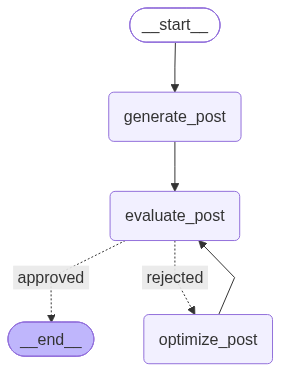

In [10]:
workflow

In [11]:
# invoke
state = {
    "topic": "AI Takeover or AI Shift? Jobs at Risk, the New Opportunities, and the Aftermath We Must Prepare For",
    "curr_iteration": 1,
    "max_iteration": 10
}

response = workflow.invoke(input=state)

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_len

In [12]:
response

{'topic': 'AI Takeover or AI Shift? Jobs at Risk, the New Opportunities, and the Aftermath We Must Prepare For',
 'post': ['**AI Takeover or AI Shift? Jobs at Risk, the New Opportunities, and the Aftermath We Must Prepare For**\n\nAs we navigate through the evolving landscape of artificial intelligence (AI), it\'s crucial to consider both the potential risks and the exciting opportunities that lie ahead. While some worry about an "AI takeover," I believe we\'re more likely to see an "AI shift"—a transformation where AI enhances our capabilities rather than replaces them.\n\nThe future is here, and it’s important for us to prepare for the jobs of tomorrow. While certain roles may become obsolete, new ones will emerge. The key is to adapt and upskill ourselves to thrive in this new era. Let\'s embrace the changes and leverage AI to create innovative solutions and drive growth.\n\nWhat do you think? Share your thoughts and insights on how we can prepare for the AI shift! 🤖💡 #AI #JobsOfTom

In [22]:
for i in range(len(response["post"])):
    print(f"\n{'=' * 80}")
    print(f"Iteration: {i + 1}")
    print(f"{'=' * 80}")

    print("\nPost:")
    print(response["post"][i])

    if i < len(response["decision"]):
        print("\nDecision:")
        print(response["decision"][i])

    if i < len(response["reasoning"]):
        print("\nReasoning:")
        print(response["reasoning"][i])


Iteration: 1

Post:
**AI Takeover or AI Shift? Jobs at Risk, the New Opportunities, and the Aftermath We Must Prepare For**

As we navigate through the evolving landscape of artificial intelligence (AI), it's crucial to consider both the potential risks and the exciting opportunities that lie ahead. While some worry about an "AI takeover," I believe we're more likely to see an "AI shift"—a transformation where AI enhances our capabilities rather than replaces them.

The future is here, and it’s important for us to prepare for the jobs of tomorrow. While certain roles may become obsolete, new ones will emerge. The key is to adapt and upskill ourselves to thrive in this new era. Let's embrace the changes and leverage AI to create innovative solutions and drive growth.

What do you think? Share your thoughts and insights on how we can prepare for the AI shift! 🤖💡 #AI #JobsOfTomorrow #FutureOfWork

Decision:
improve

Reasoning:
The post is relevant to the topic and has a clear, readable s